In [1]:
import pandas as pd
from torch.utils.data import DataLoader, ConcatDataset
from CustomDatasets import NewsDataset
import os

In [2]:
data_folder = "data/20231028"

In [3]:
data_file_paths = [os.path.join(data_folder, news) for news in os.listdir(data_folder)]
all_datasets = [NewsDataset(file_path, prompt="prompt", filter_duplicates=False) for file_path in data_file_paths]
final_dataset = ConcatDataset(all_datasets)

In [4]:
for dataset in all_datasets:
    data_file = dataset.data_file
    seen_entries = set()
    duplicate_count = 0

    for entry in data_file:
        # Create a tuple containing the values of the keys you want to check for duplicates
        unique_identifier = (entry['description'], entry['headline'], entry['main_url'], entry['content'], entry['date_published'])

        # Check if this combination has been seen before
        if unique_identifier in seen_entries:
            duplicate_count += 1
        else:
            seen_entries.add(unique_identifier)

    print(f"Number of duplicate entries in dataset: {duplicate_count}")

Number of duplicate entries in dataset: 411
Number of duplicate entries in dataset: 19


### Analysis

In [5]:
df_baselines = pd.read_csv("output/results_baselines.csv")
df_llama = pd.read_csv("output/results_llama2-7b.csv")
print(f"shape baselines = {df_baselines.shape}")
print(f"shape llama2 = {df_llama.shape}")

shape baselines = (922, 150)
shape llama2 = (800, 8)


In [6]:
df_baselines = df_baselines.drop_duplicates()
# For df_baselines
empty_columns_baselines = df_baselines.columns[df_baselines.isna().all()].tolist()
if empty_columns_baselines:
    df_baselines.drop(columns=empty_columns_baselines, inplace=True)

df_llama = df_llama.drop_duplicates()
empty_columns_llama = df_llama.columns[df_llama.isna().all()].tolist()

if empty_columns_llama:
    df_llama.drop(columns=empty_columns_llama, inplace=True)

In [7]:
print(f"shape baselines = {df_baselines.shape}")
print(f"shape llama2 = {df_llama.shape}")

shape baselines = (489, 150)
shape llama2 = (425, 7)


## Combined results preprocessing

In [8]:
df_results = pd.read_csv("output/results_baselines_llama2-7b.csv")
df_results.shape

(484, 13)

In [9]:
### problem - we have a string representation of a list that contains string representations of dictionaries
df_results["NLTK Sentiment Scores"].values[0]

'["{\'neg\': 0.034, \'neu\': 0.897, \'pos\': 0.069, \'compound\': 0.6908}", "{\'neg\': 0.034, \'neu\': 0.897, \'pos\': 0.069, \'compound\': 0.6908}"]'

In [10]:
import ast

def convert_string_representation(s):
    # Check if the input is a string
    if isinstance(s, str):
        try:
            # Attempt to convert string representation to an object (list or dict or string)
            obj = ast.literal_eval(s)

            # If it's a list containing string representations
            if isinstance(obj, list) and obj and isinstance(obj[0], str):
                # Handle case where inner representation is a dictionary
                if obj[0].startswith("{"):
                    return [ast.literal_eval(item.replace('"{', "{'").replace('}"', "'}").replace('\'', '\"')) for item in obj]

                # Handle case where inner representation is a list
                elif obj[0].startswith("["):
                    return [ast.literal_eval(item) for item in obj]

                # Handle case where inner representation is a string
                elif obj[0].startswith("\"") or obj[0].startswith("'"):
                    return [item.replace("\"", "").replace("'", "") for item in obj]
            else:
                return obj
        except (SyntaxError, ValueError):
            return s
    return s

# Apply the conversion function to all elements of the DataFrame
df_results = df_results.map(convert_string_representation)

In [11]:
### solved :)
df_results["NLTK Sentiment Scores"].values[0]

[{'neg': 0.034, 'neu': 0.897, 'pos': 0.069, 'compound': 0.6908},
 {'neg': 0.034, 'neu': 0.897, 'pos': 0.069, 'compound': 0.6908}]

In [12]:
df_results.head()

,news,timestamp,url,headline,desc,content,llama2,NLTK Sentiment Scores,NLTK Sentiment (from compound),Top 10 most common words,Financial Sentiment,News Sentiment,Political Affiliation
0,dailymail,2023-10-28T20:11:59.649326,https://www.dailymail.co.uk/wires/reuters/arti...,"Israeli military, asked about Gaza coms blacko...","JERUSALEM, Oct 28 (Reuters) - Israel's chief m...","JERUSALEM, Oct 28 (Reuters) - Israel's chief ...","[' Natural', ' I would classify this news ar...","[{'neg': 0.034, 'neu': 0.897, 'pos': 0.069, 'c...","['Positive', 'Positive']","['israel, say, military, gaza, blackout, force...","['Neutral', 'Neutral']","['Negative', 'Negative']","['Center', 'Center']"
1,dailymail,2023-10-28T20:11:59.649326,https://www.dailymail.co.uk/wires/pa/article-1...,ScotlandÂ´s First Minister does not know if hi...,Humza Yousaf is calling for an immediate cease...,Scotlandâ€™s First Minister has said he does ...,"[' Pro-Hamas', ' Pro-Hamas']","[{'neg': 0.091, 'neu': 0.845, 'pos': 0.064, 'c...","['Negative', 'Negative']","['gaza, yousaf, first, minister, said, wife, s...","['Neutral', 'Neutral']","['Negative', 'Negative']","['Center', 'Center']"
2,dailymail,2023-10-28T20:11:59.649326,https://www.dailymail.co.uk/news/article-12683...,"Eric Adams' new $143,938-a-year Racial Equity ...",Mayor Eric Adams' new appointee for chair and ...,Mayor Eric Adams' new appointee for chair and ...,"[' Pro-Palestine', ' Pro-Palestine', ' Pro-...","[{'neg': 0.104, 'neu': 0.812, 'pos': 0.084, 'c...","['Negative', 'Negative', 'Negative', 'Negative']","['palestine, protester, city, free, palestinia...","['Neutral', 'Neutral', 'Neutral', 'Neutral']","['Negative', 'Negative', 'Negative', 'Negative']","['Center', 'Center', 'Center', 'Center']"
3,dailymail,2023-10-28T20:11:59.649326,https://www.dailymail.co.uk/wires/ap/article-1...,Former Vice President Mike Pence ends campaign...,NEW YORK (AP) - Former Vice President Mike Pen...,NEW YORK (AP) - Former Vice President Mike Pe...,"[' Pro-Israel', ' Pro-Israel']","[{'neg': 0.081, 'neu': 0.836, 'pos': 0.084, 'c...","['Positive', 'Positive']","['penny, republican, president, campaign, form...","['Neutral', 'Neutral']","['Negative', 'Negative']","['Center', 'Center']"
4,dailymail,2023-10-28T20:11:59.649326,https://www.dailymail.co.uk/wires/pa/article-1...,Israel `reassessing diplomatic relations with ...,The Turkish President said his government is p...,Israel is recalling its diplomats from Turkey...,"[' Pro-Hamas', ' Pro-Hamas', ' Pro-Hamas']","[{'neg': 0.171, 'neu': 0.771, 'pos': 0.057, 'c...","['Negative', 'Negative', 'Negative']","['israel, turkey, said, war, erdogan, gaza, mr...","['Negative', 'Negative', 'Negative']","['Negative', 'Negative', 'Negative']","['Center', 'Center', 'Center']"


In [13]:
df_results.columns

Index(['news', 'timestamp', 'url', 'headline', 'desc', 'content', 'llama2',
       'NLTK Sentiment Scores', 'NLTK Sentiment (from compound)',
       'Top 10 most common words', 'Financial Sentiment', 'News Sentiment',
       'Political Affiliation'],
      dtype='object')

In [14]:
model_cols = ['llama2',
       'NLTK Sentiment Scores', 'NLTK Sentiment (from compound)',
       'Top 10 most common words', 'Financial Sentiment', 'News Sentiment',
       'Political Affiliation']

In [15]:
import json
from collections import Counter

def get_majority(values_list):
    try:
        values_list = ast.literal_eval(values_list)
        if isinstance(values_list, list):
            # Check if the list contains dictionaries
            if values_list and isinstance(values_list[0], dict):
                return values_list[0]
            else:
                count = Counter(values_list)
                majority_value, _ = count.most_common(1)[0]
                return majority_value
    except Exception:
        return values_list
    return values_list


In [16]:
df_results_ilanit = df_results.copy()

In [17]:
for col in model_cols:
    col_values = df_results_ilanit[col].values
    results = []
    for values_list in col_values:
        majority_value = get_majority(values_list)
        results.append(majority_value)
    df_results_ilanit[col] = results

In [18]:
df_results_ilanit["llama2"].values[0]

'  Natural'

In [19]:
df_results_ilanit.head()["NLTK Sentiment Scores"].values[0][0]

{'neg': 0.034, 'neu': 0.897, 'pos': 0.069, 'compound': 0.6908}

### Analysis

In [20]:
from preprocess import preprocess_df
import pandas as pd

In [21]:
df_results = pd.read_csv('output/results_baselines_llama2-7b.csv')
df_results_new = preprocess_df(df_results)

In [22]:
df_results_new.tail()

,news,timestamp,url,headline,desc,content,llama2,NLTK Sentiment Scores,NLTK Sentiment (from compound),Top 10 most common words,Financial Sentiment,News Sentiment,Political Affiliation,llama2_ant,nltk_sent_ant,nltk_sent_ant_comp,financial_sent_ant,news_sent_ant,political_aff_ant
479,bbc,2023-10-28T20:11:59.649326,https://www.bbc.co.uk/news/uk-67157564,Tributes for 'brave' British-Israeli father mu...,Yonatan Rapoport was described as 'a lovely ma...,Murdered British-Israeli man Yonatan Rapoport ...,NaN,"[""{'neg': 0.148, 'neu': 0.737, 'pos': 0.115, '...",['Negative'],"['said, hamas, rapoport, attack, killed, mothe...",['Neutral'],['Neutral'],['Center'],None,neutral,negative,neutral,neutral,center
480,bbc,2023-10-28T20:11:59.649326,https://www.bbc.co.uk/news/technology-67157733,EU gives Meta and TikTok formal Hamas disinfor...,Both firms must respond within a week to the r...,TikTok and Meta have been formally told to pro...,NaN,"[""{'neg': 0.121, 'neu': 0.838, 'pos': 0.042, '...",['Negative'],"['eu, tiktok, meta, firm, respond, information...",['Neutral'],['Negative'],['Center'],None,neutral,negative,neutral,negative,center
481,bbc,2023-10-28T20:11:59.649326,https://www.bbc.co.uk/news/world-middle-east-6...,Week 2: BBC correspondents answer your questio...,Our correspondents answer your questions on th...,The world is still reeling from the unpreceden...,NaN,"[""{'neg': 0.137, 'neu': 0.796, 'pos': 0.067, '...",['Negative'],"['israel, hamas, gaza, war, military, say, isr...",['Neutral'],['Negative'],['Center'],None,neutral,negative,neutral,negative,center
482,bbc,2023-10-28T20:11:59.649326,https://www.bbc.co.uk/news/uk-67126233,"We are broken, says brother of British Hamas v...","Nathanel Young, 20, was serving in the IDF whe...",The brother of a British man killed while serv...,NaN,"[""{'neg': 0.126, 'neu': 0.761, 'pos': 0.113, '...",['Negative'],"['said, killed, eliot, hamas, israel, brother,...",['Neutral'],['Negative'],['Center'],None,neutral,negative,neutral,negative,center
483,bbc,2023-10-28T20:11:59.649326,https://www.bbc.co.uk/news/world-middle-east-6...,Alex Danzig: Fears grow for much-loved histori...,The abduction of Holocaust expert Alex Danzig ...,"The killing of at least 1,400 people in Israel...",NaN,"[""{'neg': 0.104, 'neu': 0.789, 'pos': 0.106, '...",['Positive'],"['say, alex, israel, year, mati, holocaust, pe...",['Neutral'],['Neutral'],['Left'],None,neutral,positive,neutral,neutral,left


In [23]:
df_results_new.columns

Index(['news', 'timestamp', 'url', 'headline', 'desc', 'content', 'llama2',
       'NLTK Sentiment Scores', 'NLTK Sentiment (from compound)',
       'Top 10 most common words', 'Financial Sentiment', 'News Sentiment',
       'Political Affiliation', 'llama2_ant', 'nltk_sent_ant',
       'nltk_sent_ant_comp', 'financial_sent_ant', 'news_sent_ant',
       'political_aff_ant'],
      dtype='object')

### 1. Plotting Sentiments & Political Affiliation by Newspaper:

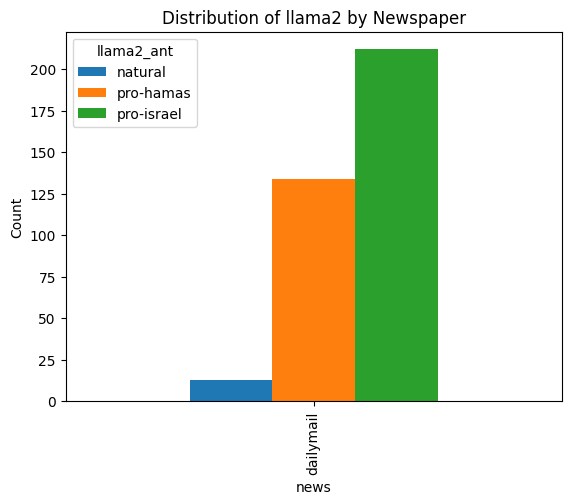

In [24]:
import matplotlib.pyplot as plt

llama2_counts = df_results_new.groupby(['news', 'llama2_ant']).size().unstack().fillna(0)

# Plotting the data
llama2_counts.plot(kind='bar')
plt.title('Distribution of llama2 by Newspaper')
plt.ylabel('Count')
plt.show()


### 2. Plotting nltk Sentiment Score as a Function of Time Grouped by Newspaper:

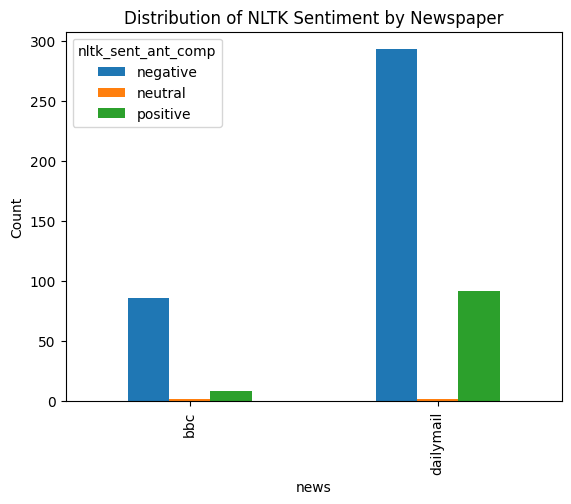

In [25]:
nltk_counts = df_results_new.groupby(['news', 'nltk_sent_ant_comp']).size().unstack().fillna(0)

nltk_counts.plot(kind='bar')
plt.title('Distribution of NLTK Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()


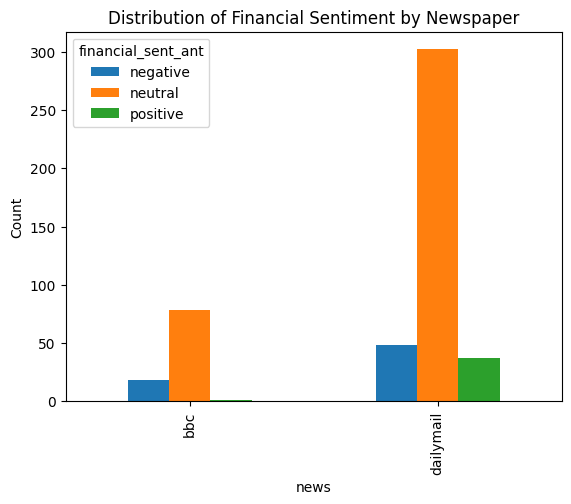

In [26]:
fin_sentiment_counts = df_results_new.groupby(['news', 'financial_sent_ant']).size().unstack().fillna(0)

fin_sentiment_counts.plot(kind='bar')
plt.title('Distribution of Financial Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()

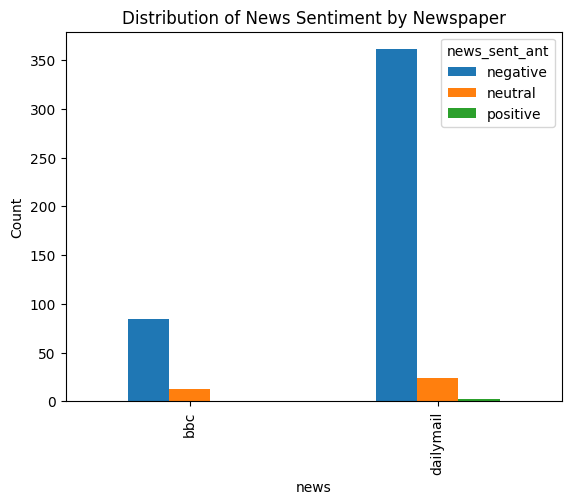

In [27]:
fin_sentiment_counts = df_results_new.groupby(['news', 'news_sent_ant']).size().unstack().fillna(0)

fin_sentiment_counts.plot(kind='bar')
plt.title('Distribution of News Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()

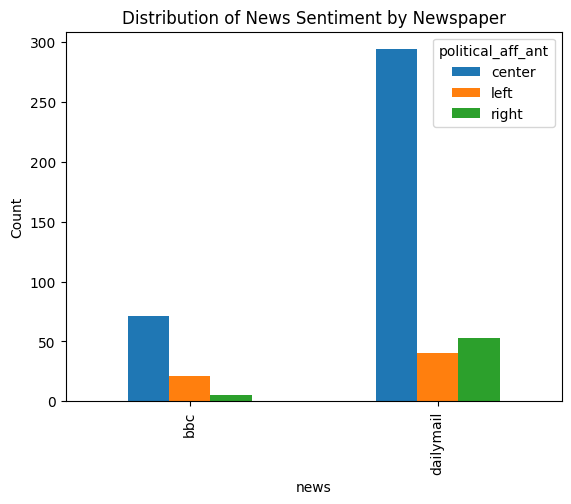

In [28]:
fin_sentiment_counts = df_results_new.groupby(['news', 'political_aff_ant']).size().unstack().fillna(0)

fin_sentiment_counts.plot(kind='bar')
plt.title('Distribution of News Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()

### 3. Plotting a Word Cloud Grouped by Newspaper:

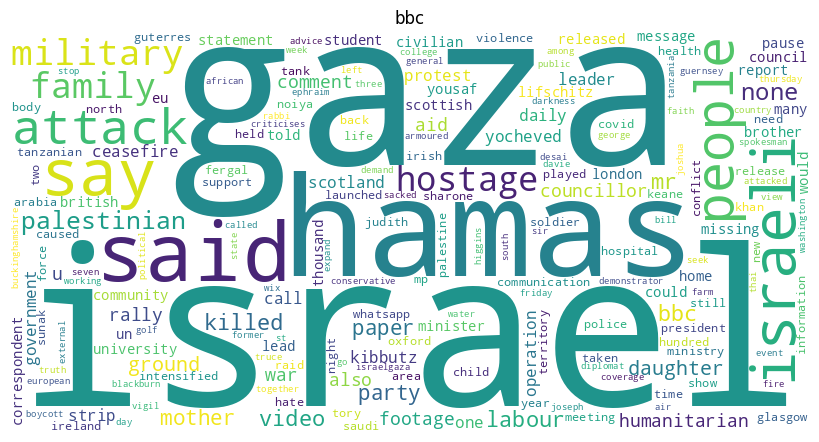

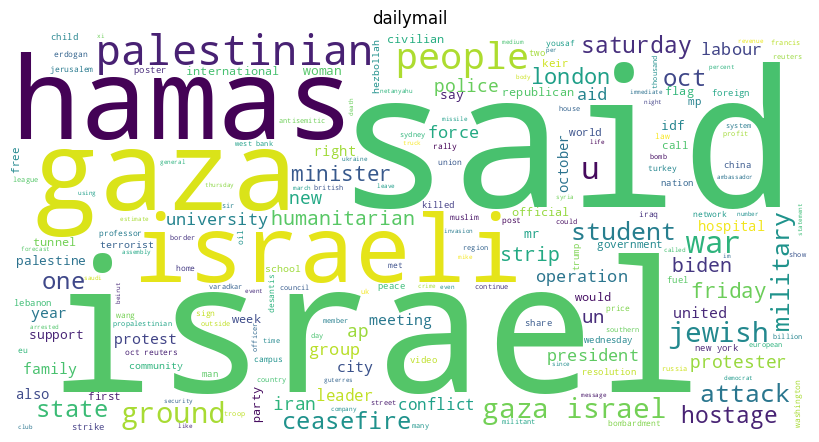

In [29]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

for name, group in df_results_ilanit.groupby('news'):
    text = ' '.join(group['Top 10 most common words'])
    wordcloud = WordCloud(width=800, height=400, background_color ='white', stopwords = stop_words).generate(text)
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.title(name)
    plt.show()

### 4. Agreement Metrics

{'Kappa': 0.0, 'Krippendorff  alpha': -0.4999118694257412, 'Scott pi': -0.5014629675326964, 'Bennett s': -0.25}
-------------------------------------------------------------
{'Kappa': 0.0, 'Krippendorff  alpha': -0.3287341441533518, 'Scott pi': -0.3301082228960129, 'Bennett s': -0.16666666666666666}
-------------------------------------------------------------
{'Kappa': 0.0, 'Krippendorff  alpha': -0.321870278056289, 'Scott pi': -0.3232372586954373, 'Bennett s': -0.16666666666666666}
-------------------------------------------------------------
{'Kappa': 0.0, 'Krippendorff  alpha': -0.4205653997681096, 'Scott pi': -0.4220344436148192, 'Bennett s': -0.16666666666666666}
-------------------------------------------------------------
{'Kappa': 0.0, 'Krippendorff  alpha': -0.3036628506169745, 'Scott pi': -0.30501100247903956, 'Bennett s': -0.16666666666666666}
-------------------------------------------------------------
{'Kappa': 0.0, 'Krippendorff  alpha': -0.4999118694257412, 'Scott pi':

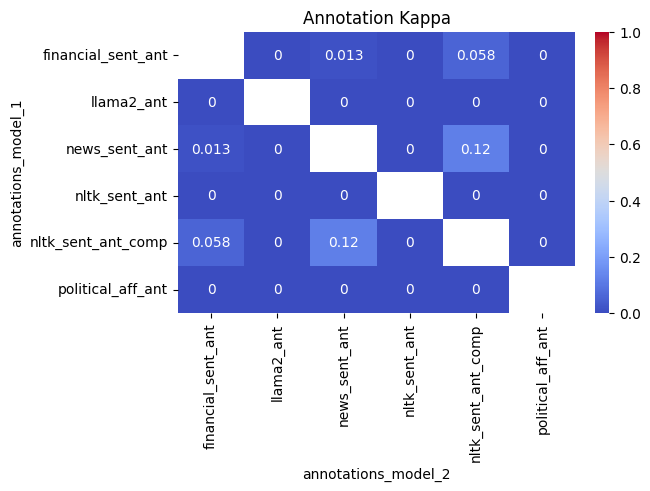

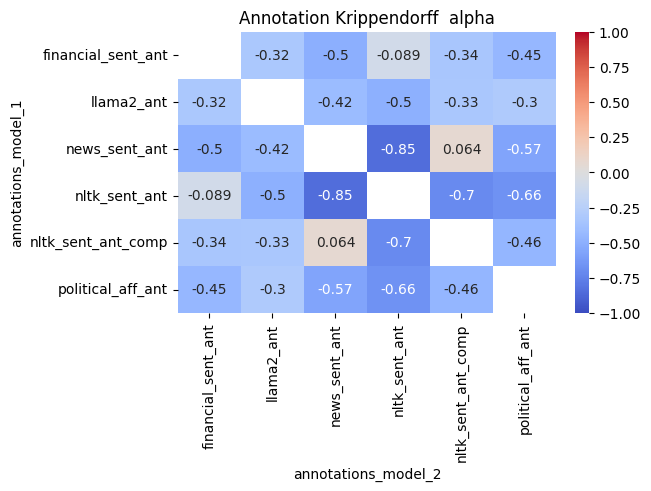

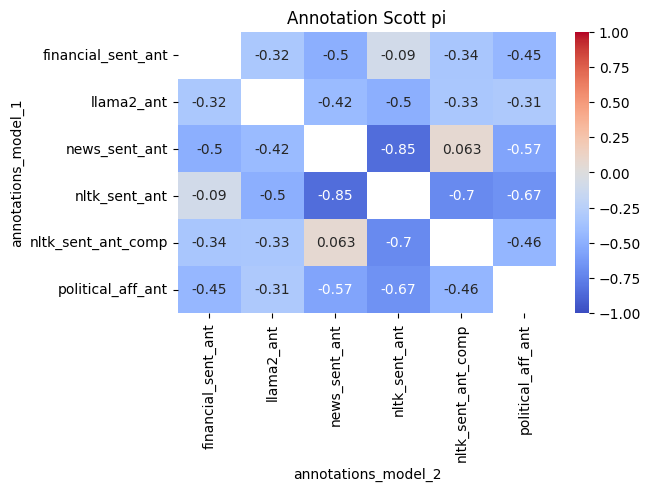

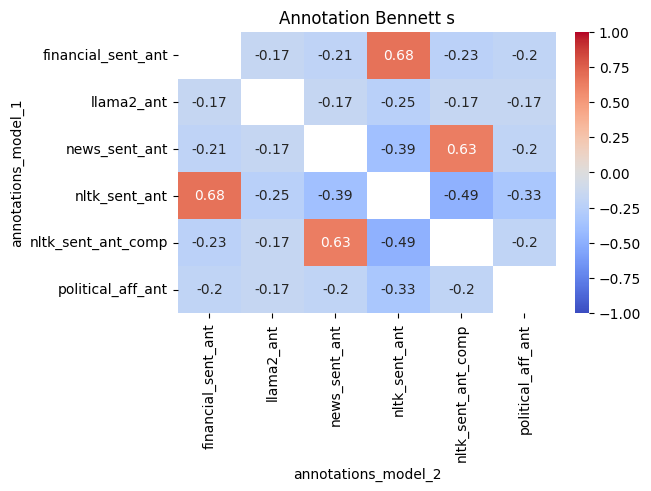

In [30]:
from Agreement_statistics import measure_agreement, show_heatmap
cols = ['llama2_ant', 'nltk_sent_ant', 'nltk_sent_ant_comp',
            'financial_sent_ant', 'news_sent_ant', 'political_aff_ant']

records = []
for col in cols:
    for col2 in cols:
        if col == col2:
            continue
        try:
            agreements = measure_agreement(df_results_new.copy(), col, col2)
            print(agreements)
            records.append((col, col2, agreements['Kappa'], agreements['Krippendorff  alpha'],
                            agreements['Scott pi'], agreements['Bennett s']))
        except Exception as error:
            print(error)
            print(col)
            print(col2)
            records.append((col, col2, None, None, None, None))
        print("-------------------------------------------------------------")
df = pd.DataFrame.from_records(records, columns=['annotations_model_1', 'annotations_model_2', 'Kappa',
                                                 'Krippendorff  alpha', 'Scott pi',
                                                 'Bennett s'])
df.to_csv('output/agreements.csv', index=False)
for metric in ['Kappa', 'Krippendorff  alpha', 'Scott pi', 'Bennett s']:
    if metric == 'Kappa':
        show_heatmap(df, metric, 0)
    else:
        show_heatmap(df, metric,-1)

### 5. Temporal Analysis

In [31]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import ast
from dateutil.parser import parse


In [32]:
# Add new columns to the dataframe
df_results_ilanit["date_published"] = ""
df_results_ilanit["date_modified"] = ""

for dataset in all_datasets:
    data_file = dataset.data_file
    for entry in data_file:
        url = entry['url']
        date_published = entry["date_published"]
        date_modified = entry["date_modified"]

        # Find indices where content matches
        matching_indices = df_results_ilanit[df_results_ilanit.url == url].index

        # Update date_published and date_modified for those indices
        df_results_ilanit.loc[matching_indices, "date_published"] = date_published
        df_results_ilanit.loc[matching_indices, "date_modified"] = date_modified


In [33]:
df_results_ilanit["date_published"]

0      2023-10-28T20:13:38+01:00
1      2023-10-28T19:56:41+01:00
2      2023-10-28T19:54:29+01:00
3      2023-10-28T19:37:55+01:00
4      2023-10-28T19:31:41+01:00
                 ...            
479          2023-10-19T16:07:22
480          2023-10-19T13:42:13
481          2023-10-16T20:24:36
482          2023-10-16T17:35:17
483          2023-10-18T16:24:15
Name: date_published, Length: 484, dtype: object

In [34]:

def convert_date(date_str):
    if date_str is None:
        return None

    try:
        return datetime.datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S%z")
    except ValueError:
        try:
            return datetime.datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S")
        except ValueError:
            try:
                return datetime.datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S.%f")
            except ValueError:
                # Handle or log the error, if necessary
                print(f"Failed to parse date: {date_str}")
                return None

def infer_datetime_format(date_str):
    try:
        return parse(date_str)
    except ValueError:
        return None

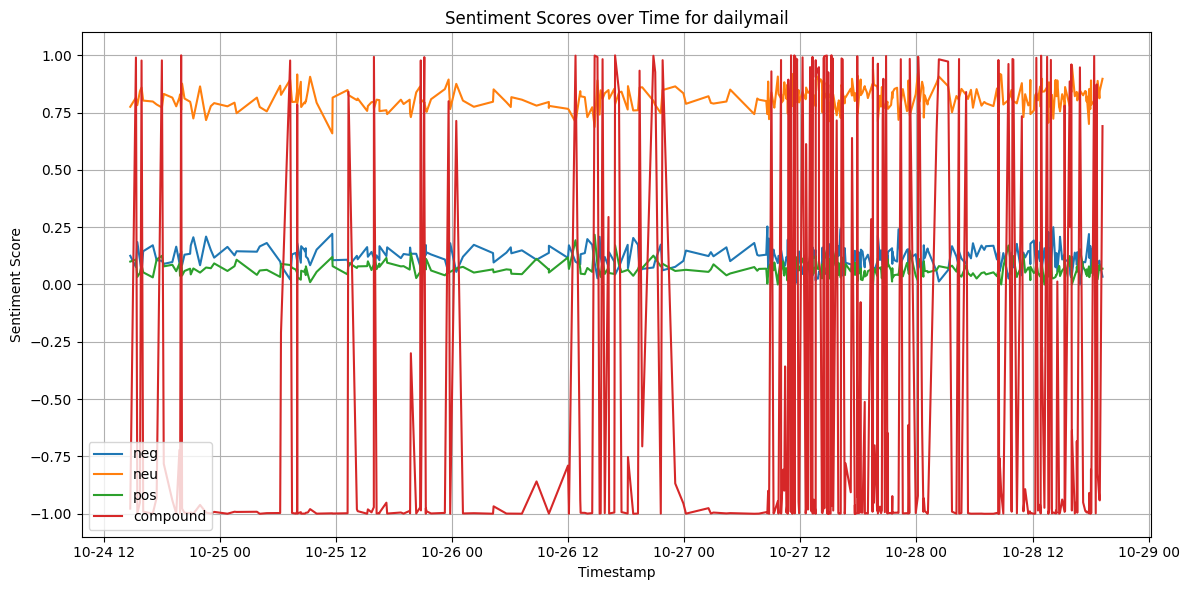

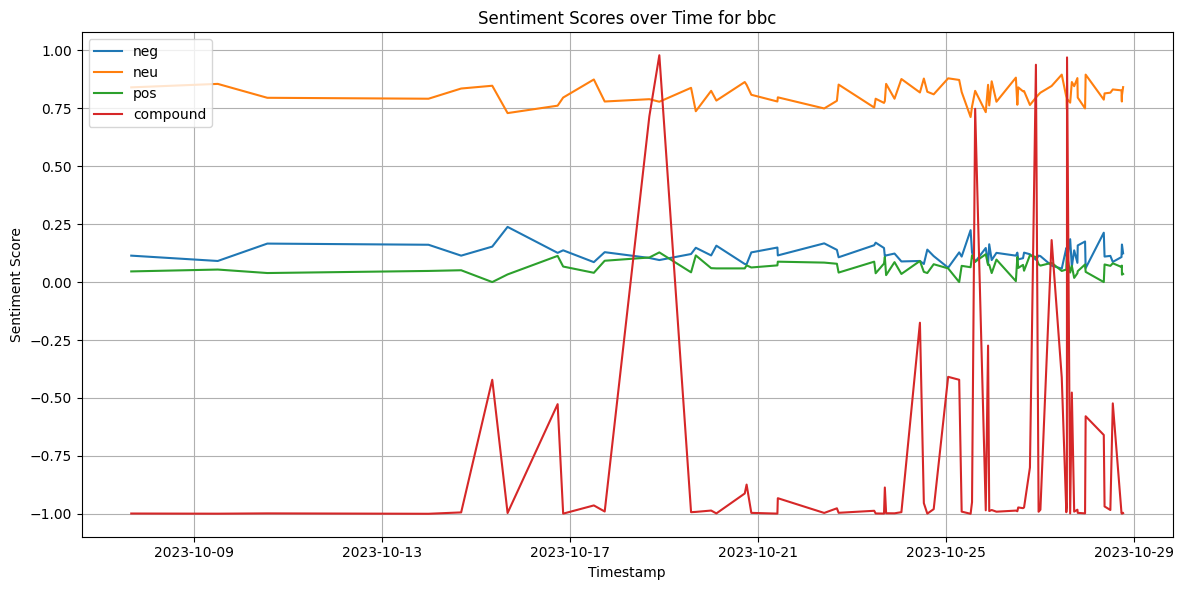

In [35]:
for news in df_results_ilanit.news.unique():
    curr_df = df_results_ilanit[df_results_ilanit.news == news]

    # Plotting the sentiments as a function of timestamp
    plt.figure(figsize=(12, 6))
    for sentiment in ['neg', 'neu', 'pos', 'compound']:
        first_sentiments = curr_df["NLTK Sentiment Scores"].apply(lambda x: x[0] if x else {})
        sentiments = first_sentiments.apply(lambda x: x.get(sentiment, None))

        # Convert dates and filter out None or NaT values
        converted_dates = curr_df['date_published'].apply(convert_date)
        mask = ~pd.isnull(converted_dates)
        sentiments = sentiments[mask]

        # Convert to datetime and adjust to UTC timezone
        converted_dates = pd.to_datetime(converted_dates[mask], errors='coerce')
        if not all(date.tzinfo for date in converted_dates):
            converted_dates = converted_dates.dt.tz_localize('UTC', ambiguous='infer', nonexistent='shift_forward')
        else:
            converted_dates = converted_dates.dt.tz_convert('UTC')

        # Sort the dates
        sorted_idx = converted_dates.sort_values().index
        plt.plot(converted_dates.loc[sorted_idx], sentiments.loc[sorted_idx], label=sentiment)

    plt.title(f"Sentiment Scores over Time for {news}")
    plt.xlabel("Timestamp")
    plt.ylabel("Sentiment Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Topic modeling

In [36]:
from nltk.tokenize import sent_tokenize

texts = df_results_ilanit.content.values
texts = [x for x in texts if type(x) == str]
sentences = [sent_tokenize(text) for text in texts]
sentences = [sentence for doc in sentences for sentence in doc]

In [37]:
len(sentences)

12818

In [39]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech

# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm")

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

representation_models = {
    "KeyBERT": keybert_model,
    "MMR": mmr_model,
    "POS": pos_model
}

In [50]:
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))
keybert_model = KeyBERTInspired()
topic_model = BERTopic(
    ctfidf_model=ctfidf_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=50,
    n_gram_range = (1,2),
    representation_model = representation_models,
      top_n_words=10,
      verbose=True
)

In [51]:
topics, _ = topic_model.fit_transform(sentences)

Batches:   0%|          | 0/401 [00:00<?, ?it/s]

2023-10-31 13:57:50,675 - BERTopic - Transformed documents to Embeddings
2023-10-31 13:57:57,488 - BERTopic - Reduced dimensionality
2023-10-31 13:57:58,052 - BERTopic - Clustered reduced embeddings


In [52]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,5329,-1_people_israeli_hamas_video,"[people, israeli, hamas, video, gaza, said, is...","[hamas, gaza, gaza strip, israeli, palestinian...","[people, israeli, hamas, video, gaza, said, is...","[people, video, military, war, civilians, news...","[Instead, they wanted to take the fight to Isr..."
1,0,774,0_police_protesters_officers_london,"[police, protesters, officers, london, flags, ...","[palestinian flags, palestinian flag, palestin...","[police, protesters, officers, london, flags, ...","[police, protesters, officers, flags, demonstr...",['Met Police Commissioner Sir Mark Rowley diff...
2,1,639,1_dont_im_know_life,"[dont, im, know, life, dont know, thats, want,...","[future, life, family, families, triumph, said...","[dont, im, know, life, dont know, thats, want,...","[life, planet, time, just, families, answers, ...","[""I am a better person because I have had the ..."
3,2,621,2_israel right_right defend_defend_right,"[israel right, right defend, defend, right, in...","[defend hamas, condemning hamas, hamas israel,...","[israel right, right defend, defend, right, in...","[right, international law, terrorist, law, att...",[READ MORE:Â Fury as Islamists chant Hamas slo...
4,3,483,3_oil_billion_prices_profit,"[oil, billion, prices, profit, earnings, quart...","[stocks, forecasts, markets, investors, federa...","[oil, billion, prices, profit, earnings, quart...","[oil, prices, profit, earnings, quarter, share...",[ Amazon.com says growth in cloud business sta...
5,4,454,4_republican_johnson_vegas_las vegas,"[republican, johnson, vegas, las vegas, las, p...","[republican jewish, jewish coalition, jewish v...","[republican, johnson, vegas, las vegas, las, p...","[candidates, president, vice, campaign, effect...",[The Republican Jewish Coalition's annual gath...
6,5,441,5_students_university_student_professor,"[students, university, student, professor, jew...","[jewish students, called hamas, nyu students, ...","[students, university, student, professor, jew...","[students, university, student, campus, school...",[NYU students held up antiSemitic 'keep the wo...
7,6,357,6_health ministry_ministry_killed_health,"[health ministry, ministry, killed, health, pe...","[killed gaza, palestinians killed, hamas kille...","[health ministry, ministry, killed, health, pe...","[ministry, health, strikes, people, retaliator...","['The Palestinian death toll passed 7,300 as I..."
8,7,328,7_labour_keir_sir_sir keir,"[labour, keir, sir, sir keir, mps, party, star...","[labour mps, muslim mps, labour councillors, l...","[labour, keir, sir, sir keir, mps, party, star...","[leader, councillors, position, ceasefire, res...",[Keir Starmer is facing a major Labour rebelli...
9,8,274,8_kibbutz_oz_nir oz_nir,"[kibbutz, oz, nir oz, nir, mother, lifschitz, ...","[taken hostage, yocheved lifshitz, kidnapped, ...","[kibbutz, oz, nir oz, nir, mother, lifschitz, ...","[kibbutz, mother, husband, father, family, bro...","[Ms Lifschitz was kidnapped, alongside her hus..."


In [55]:
topic_model.visualize_barchart()

In [53]:
topic_model.visualize_hierarchy()

In [54]:
topic_model.visualize_topics()

In [ ]:
### Advanced - LLAMA2

In [ ]:
from torch import cuda

model_id = 'meta-llama/Llama-2-7b-chat-hf'
device = f'cuda:{cuda.current_device()}' if cuda.is_available() else 'cpu'

print(device)

In [ ]:
from torch import bfloat16
import transformers

# set quantization configuration to load large model with less GPU memory
# this requires the `bitsandbytes` library

bnb_config = transformers.BitsAndBytesConfig(
    load_in_4bit=True,  # 4-bit quantization
    bnb_4bit_quant_type='nf4',  # Normalized float 4
    bnb_4bit_use_double_quant=True,  # Second quantization after the first
    bnb_4bit_compute_dtype=bfloat16  # Computation type
)

In [ ]:
# Llama 2 Tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained(model_id)

# Llama 2 Model
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    quantization_config=bnb_config,
    device_map='auto',
)
model.eval()

In [ ]:
# Our text generator
generator = transformers.pipeline(
    model=model, tokenizer=tokenizer,
    task='text-generation',
    temperature=0.1,
    max_new_tokens=500,
    repetition_penalty=1.1
)

In [ ]:
# System prompt describes information given to all conversations
system_prompt = """
<s>[INST] <<SYS>>
You are a helpful, respectful and honest assistant for labeling topics.
<</SYS>>
"""
# Example prompt demonstrating the output we are looking for
example_prompt = """
I have a topic that contains the following documents:
- Traditional diets in most cultures were primarily plant-based with a little meat on top, but with the rise of industrial style meat production and factory farming, meat has become a staple food.
- Meat, but especially beef, is the word food in terms of emissions.
- Eating meat doesn't make you a bad person, not eating meat doesn't make you a good one.

The topic is described by the following keywords: 'meat, beef, eat, eating, emissions, steak, food, health, processed, chicken'.

Based on the information about the topic above, please create a short label of this topic. Make sure you to only return the label and nothing more.

[/INST] Environmental impacts of eating meat
"""
# Our main prompt with documents ([DOCUMENTS]) and keywords ([KEYWORDS]) tags
main_prompt = """
[INST]
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the information about the topic above, please create a short label of this topic. Make sure you to only return the label and nothing more.
[/INST]
"""

In [ ]:
prompt = system_prompt + example_prompt + main_prompt

In [ ]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
embedding_model = SentenceTransformer("BAAI/bge-small-en")
embeddings = embedding_model.encode(sentences, show_progress_bar=True)

In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=150, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

In [ ]:
# Pre-reduce embeddings for visualization purposes
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings)

In [ ]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, TextGeneration

# KeyBERT
keybert = KeyBERTInspired()

# MMR
mmr = MaximalMarginalRelevance(diversity=0.3)

# Text generation with Llama 2
llama2 = TextGeneration(generator, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert,
    "Llama2": llama2,
    "MMR": mmr,
}

In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(

  # Sub-models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics, probs = topic_model.fit_transform(sentences, embeddings)


In [ ]:
# Show topics
topic_model.get_topic_info()

In [ ]:
llama2_labels = [label[0][0].split("\n")[0] for label in topic_model.get_topics(full=True)["Llama2"].values()]
topic_model.set_topic_labels(llama2_labels)

In [ ]:
topic_model.visualize_documents(sentences, reduced_embeddings=reduced_embeddings, hide_annotations=True, hide_document_hover=False, custom_labels=True)

In [ ]:
topic_model.visualize_hierarchy(custom_labels=True)

In [ ]:
topic_model.visualize_heatmap(custom_labels=True)

In [ ]:
topic_model.visualize_barchart(custom_labels=True)